In [ ]:
'''
Author: James Jolly
Date Created: Apr 18, 2025

Purpose: This file is useds to generate graphs looking at the matching of GT Windows (and maybe points) to the detections of TallyNet
'''

In [1]:
import logging
logging.getLogger('tensorflow').disabled = True

# TensorFlow, keras, np
import tensorflow as tf
from tensorflow import keras
import numpy as np
import time
import sys

from io import UnsupportedOperation
import pickle as pkl


# Add shared location for auxillary functions
sys.path.insert(1, './../AuxillaryFunctions')

# import personal Functions
from GenerateClassDataFuncs import GenerateEvalData_ClemCafe
from GenerateClassDataFuncs import GenerateEvalData_OREBA

from EvaluationMethodFuncs import TimePoint2Window
from EvaluationMethodFuncs import Window2TimePoint
from EvaluationMethodFuncs import DongEval_PtVsPt
from EvaluationMethodFuncs import KyritEval_PtVsWindow
from EvaluationMethodFuncs import Duration_WindowVsWindow
from EvaluationMethodFuncs import PrintStats

from DetectionPlacementFuncs import Cnt2Detect_MidpointTriggerMidpointPlacement
from DetectionPlacementFuncs import Cnt2Detect_TetrisBlockFilling
from DetectionPlacementFuncs import Cnt2Detect_TemplateMatching
from DetectionPlacementFuncs import Cnt2Detect_TetrisBlockFilling_Midpt

# load graphing libraries
import matplotlib.pyplot as plt

from GenerateClassDataFuncs import GenerateTallyCounts

print("Finished Importing Libraries")

Finished Importing Libraries


In [3]:
SAVE_PREDICITONS_FLAG = 0
	# Saves the predictions to a CSV
SAVE_DETECTIONS_FLAG = 0
SAVE_GT_FLAG = 0
DEBUG_PRINTS = 0
	# Set to 1 for additional Prints throughout the file,
	# clear to 0 for only final output
VERBOSE_PRINT = 0
	# set to 1 for Lengthy Output, 0 for single line
TIMING_PRINT = 0 
	# Set to 1 if prints for times should be made, 0 if not desired

EVAL_METHOD_FLAG = 2
	# 1 = Dong Eval (Pt vs Pt)
	# 2 = Kyritsis (Pt vs Window)
	# 3 = Duration (Window vs Window)
EVAL_METHOD_NAMES = ["Names for Eval methods (valid flags start at 1)",
					 "Dong_PtVsPt",
					 "Kyritsis_PtVsWind",
					 "Duration_WindVsWind"]
# If using Kyritsis, these constants will be used
# WIN_TOLERANCE = 0.0 
WIN_TOLERANCE = 8
	# default to 0.0 for strict method, otherwise provide [sec] preds can be away from window

SCALE_FACTOR_FOR_BITE_COUNTS = 0
	# Used if Scaling the model predictions.  Set to 0 if not using, and any other value if so

MATCH_THRESH = 0.75



if EVAL_METHOD_FLAG == 2 or EVAL_METHOD_FLAG == 3:
	GT_WINDOW_FLAG = 1 #mark that we want Windows from GT if using a window metric
else:
	GT_WINDOW_FLAG = 0 # mark that we want time points for GT metrics
# end of Window vs Point GT Flag

#define constants for the data
if True:
	MODEL_NAME = "Models/THO_A1232_0/models/fold1"
	FOLDS_TOTAL = 5
	DATABASE_FLAG = 2
	FOLD_INDEX = 1 # wrap data into valid fold number in case fold 
				# index is given as [1,FOLDS_TOTAL] instead of [0,FOLDS_TOTAL) 
elif True:
	MODEL_NAME = "Models/Clem_A300_0/models/fold1"
	FOLDS_TOTAL = 10
	DATABASE_FLAG = 3
	FOLD_INDEX = 1 # wrap data into valid fold number in case fold 
				# index is given as [1,FOLDS_TOTAL] instead of [0,FOLDS_TOTAL) 
elif False:
	MODEL_NAME = "Models/THO_A300_0/models/fold1"
	FOLDS_TOTAL = 5
	DATABASE_FLAG = 2
	FOLD_INDEX = 1  
				# index is given as [1,FOLDS_TOTAL] instead of [0,FOLDS_TOTAL)
elif False:
	MODEL_NAME = "Models/OHO_A300_0/models/fold1"
	FOLDS_TOTAL = 5
	DATABASE_FLAG = 1
	FOLD_INDEX = 1 # wrap data into valid fold number in case fold 
				# index is given as [1,FOLDS_TOTAL] instead of [0,FOLDS_TOTAL) 
# End of database selection

RR_FLAG = 1 # 1 if using striped fold division, 0 if using block fold division
CUT_sec = 15 # the total length of the window in [sec]
STRIDE_sec = 1 # The time to move between each window when making examples in [sec]

RESAMPLE_FLAG_FREQ = 15 # zero if keeping original data frequency, new freq otherwise

if False: #eventually edit to include DOWN SAMPLING OPTIONS
	max_input_index = 8
	DS_FLAG = int(sys.argv[max_input_index+1]) # 1 = linear interp, 2 = Cubic Interp
	DS_Rate = int(sys.argv[max_input_index+2])
	DS_Delay = int(sys.argv[max_input_index+3])
# end of DS Segment to eventually add
if False: #Potentially add Smoothing back into file
	SMOOTHING = int(sys.argv[max_input_index+4])
# end of Smoothing Eventual Expansion
if SAVE_PREDICITONS_FLAG==1:
	output_CSV_name = "Predictions/preds_OHO_A300_0/"
	print("output_CSV_name = {}".format(output_CSV_name))
# end of SAVE_PREDICITONS_FLAG

if DATABASE_FLAG == 1:
	DATABASE_FILEPATH = "./../Pickle_Databases/OREBA.pkl"
elif DATABASE_FLAG == 2:
	DATABASE_FILEPATH = "./../Pickle_Databases/OREBA_TwoHands.pkl"
elif DATABASE_FLAG == 3:
	DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"
else:
	print("!!! WARNING: INVALID DATABASE SELECTION FLAG VALUE OF {} !!!".format(DATABASE_FLAG))
	print("Expects value of:")
	print("\t1 = OneHand OREBA")
	print("\t2 = TwoHand OREBA")
	print("\t3 = ClemCafe Data")
	print("Defaulting to use of ClemCafeData...")
	DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"
#end of Database switch statement



SMOOTHING_FACTOR = 0 # the number of data points to either side to smooth the raw data
WINDOWS_PER_BATCH = 128 # Batch-size for the model


if DEBUG_PRINTS == 1:
	print('CUT_sec Input is ',CUT_sec)
	print('STRIDE_sec input is ',STRIDE_sec)
	print('Training Data coming from file ',DATABASE_FILEPATH)
	print('RR_Flag Input is ',RR_FLAG)
	print('Fold_Index Input is ',FOLD_INDEX)
	print('Folds_Total Input is ',FOLDS_TOTAL)
	print('Resample Rate Input is ',RESAMPLE_FLAG_FREQ)
	print('Eval Method is ',EVAL_METHOD_NAMES[EVAL_METHOD_FLAG])
	print('WIN_TOLERANCE (if needed) is ',WIN_TOLERANCE)
	print("python setup complete")
# end of DEBUG_PRINTS

if TIMING_PRINT == 1:
	print("Parsing Eval Data...")
	start=time.time()
# end of TIMING_PRINT

if DATABASE_FLAG == 1 or DATABASE_FLAG == 2:
	if RESAMPLE_FLAG_FREQ == 0:
		DataFreq = 64 # Frequency of Data Collection in [Hz]
	else:
		DataFreq = RESAMPLE_FLAG_FREQ # New [Hz] to which to convert signal
	compiled_eval_data = GenerateEvalData_OREBA(
			int(round(CUT_sec*DataFreq)), int(round(STRIDE_sec*DataFreq)),
			DATABASE_FILEPATH,
			FOLD_INDEX,	FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
			RESAMPLE_FLAG=RESAMPLE_FLAG_FREQ,
			GT_WINDOW_FLAG = GT_WINDOW_FLAG
			)
	# NOTE: Pass GT_WINDOW_FLAG into OREBA because the original GT is given in Windows
elif DATABASE_FLAG == 3:
	if RESAMPLE_FLAG_FREQ == 0:
		DataFreq = 15 # Frequency of Data Collection in [Hz]
	else:
		DataFreq = RESAMPLE_FLAG_FREQ # New [Hz] to which to convert signal
	compiled_eval_data = GenerateEvalData_ClemCafe(
			int(round(CUT_sec*DataFreq)), int(round(STRIDE_sec*DataFreq)),
			DATABASE_FILEPATH,
			FOLD_INDEX, FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
			RESAMPLE_FLAG=RESAMPLE_FLAG_FREQ # Frequency of Data Collection in [Hz]
			#, RESAMPLE_FLAG=0, SMOOTHING=0 # optional flags not currently used for Paper Experiment
			)
	# NOTE: Pass GT_WINDOW_FLAG into OREBA because the original GT is given in Windows
	if GT_WINDOW_FLAG == 1:
		for meal_num in range(len(compiled_eval_data)):
			compiled_eval_data[meal_num][3] = TimePoint2Window(np.array(compiled_eval_data[meal_num][3])) # default is 2.5 seconds per bite, centered
	# end of if Converting GT to Windows
#end of Database switch statement
# Set values to minimum threshold now that data frequency has been defined 
if CUT_sec == 0:
	CUT_sec = 1/DataFreq
if STRIDE_sec == 0 :
	STRIDE_sec = 1/DataFreq

if TIMING_PRINT == 1:
	end=time.time()
	print("...Eval data parsed in ",end-start," seconds")

	print("Loading Model and Predicting Data...")
	start=time.time()
# end of TIMING_PRINT

print("Finished setting all parameters.")

Finished setting all parameters.


In [4]:

# load keras model
model = tf.keras.models.load_model(MODEL_NAME)

print("Finished Loading Model.")

Finished Loading Model.


In [6]:
All_TP=[] # List (one entry per file) of bites that trigger within ground truth
All_FP=[] # List of Bites that trigger but have already been mapped to a TP
All_FN=[] # List of GT windows without a bite detected

All_Preds = []
All_Detections = [] 
All_GT_Times = []
All_meal_nums = []


for currEvalIndex in range(len(compiled_eval_data)):

	meal_num,features_input,timestep_ref,gt_bite_times = compiled_eval_data[currEvalIndex]

	##############################################
	##### Bite Count portion of Eval (bc.py) #####
	##############################################

	predictions = model.predict(features_input)
	#predictions = np.ones([len(features_input),1]) # quick fake predicitions for debugging
	if SCALE_FACTOR_FOR_BITE_COUNTS > 0:
		predictions = predictions / SCALE_FACTOR_FOR_BITE_COUNTS
	# end if SCALE_FACTOR_FOR_BITE_COUNTS

	if SAVE_PREDICITONS_FLAG == 1:
		csvfilename = output_CSV_name + "_MN" + "{:03}".format(meal_num) + ".csv"
		with open(csvfilename,'w') as fp:
			for i in range(len(predictions)):
				fp.write("{:.4f},\n".format(float(predictions[i,0])))
			# end of for loop
		#end of with fp
	#end if SAVE_PREDICTIONS_FLAG
	
	
	if False: # Smoothing
		SMOOTHING_REACH = 8
		predictions_OG = predictions.copy()
		for i in range(SMOOTHING_REACH,len(predictions)-SMOOTHING_REACH):
			predicitions[i] = sum(predictions_OG[i-SMOOTHING_REACH:i+SMOOTHING_REACH])/(SMOOTHING_REACH*2+1)
		# end
	# end of smoothing if
		


	if TIMING_PRINT == 1:
		end=time.time()
		print("...Predictions made in ",end-start," seconds")
		print("Calculating bite locations from predictions...")
		start=time.time()
	# end of TIMING_PRINT

	# Convert Prediction Counts into detections of events
	DetectionPlacementFlag = 1
		# 1 = Midpoint Trigger, Midpoint Placement
		# 2 = Tetris Block Filling and trigger
		# 3 = FUTURE WORK IDEA: Template Matching Search
	if DetectionPlacementFlag == 1:
		Detections = Cnt2Detect_MidpointTriggerMidpointPlacement(predictions, timestep_ref, STRIDE_sec, CUT_sec)
	elif DetectionPlacementFlag == 2:
		Detections = Cnt2Detect_TetrisBlockFilling(predictions, timestep_ref, STRIDE_sec, CUT_sec)
	elif DetectionPlacementFlag == 3:
		Detections = Cnt2Detect_TemplateMatching(predictions, timestep_ref, STRIDE_sec, CUT_sec, MATCH_THRESH=MATCH_THRESH)
	elif DetectionPlacementFlag == 4:
		Detections = Cnt2Detect_TetrisBlockFilling_Midpt(predictions, timestep_ref, STRIDE_sec, CUT_sec)
	# end of if Cnt2Detect

	if TIMING_PRINT == 1:
		end=time.time()
		print("...Bites Placed in ",end-start," seconds")
	# end of TIMING_PRINT

	##############################################
	#### Evaluation Portion of Eval (eval.c) #####
	##############################################
	'''
	#####################################################################################
	#####################################################################################
	######### WORK ON #############
	#####################################################################################
	#####################################################################################
	'''

	# Convert to np-array to use Eval function 
	Detections = np.array(Detections)
	gt_bite_times = np.array(gt_bite_times)
	

	if SAVE_DETECTIONS_FLAG == 1:
		csvfilename = output_CSV_name + "Detections_MN" + "{:03}".format(meal_num) + ".csv"
		print("Detection CSV name is {}".format(csvfilename))
		with open(csvfilename,'w') as fp:
			for i in range(len(Detections)):
				fp.write("{:.3f}\n".format(float(Detections[i])))
			# end of for loop
		#end of with fp
	#end if SAVE_PREDICTIONS_FLAG
	if SAVE_GT_FLAG == 1:
		csvfilename = output_CSV_name + "GT_MN" + "{:03}".format(meal_num) + ".csv"
		with open(csvfilename,'w') as fp:
			for i in range(len(gt_bite_times)):
				if GT_WINDOW_FLAG == 1:
					fp.write("{:.3f},{:.3f}\n".format(float(gt_bite_times[i,0]),float(gt_bite_times[i,1])))
				else:
					fp.write("{:.3}\n".format(float(gt_bite_times[i])))
			# end of for loop
		#end of with fp
	#end if SAVE_PREDICTIONS_FLAG

	if EVAL_METHOD_FLAG == 1:
		[TP, FP, FN, Key] = DongEval_PtVsPt(Detections, gt_bite_times)
	elif EVAL_METHOD_FLAG == 2:
		# GT Should have already be converted to Windows
		[TP, FP, FN, FP1, FP2, Key] = KyritEval_PtVsWindow(Detections, gt_bite_times,WIN_TOLERANCE = WIN_TOLERANCE)
	elif EVAL_METHOD_FLAG == 3:
		# Convert Predictions to windows
		Detections_wind = TimePoint2Window(Detections)
		# GT Should have already be converted to Windows
		[TP, FP, FN, TN, Key] = Duration_WindowVsWindow(Detections_wind, gt_bite_times)
	else:
		print("ERROR: UNKNOWN EVAL METHOD REQUESTED. Please pass in 1 for Dong_PtVSPt, 2 for Kyritsis_PtVsWindow, and 3 for Duration_WindVsWind.")
		raise Exception("ERROR: UNKNOWN EVAL METHOD REQUESTED. Please pass in 1 for Dong_PtVSPt, 2 for Kyritsis_PtVsWindow, and 3 for Duration_WindVsWind.")
	#end of EVAL_METHOD_FLAG Switch
	
	
	All_Preds.append(predictions)
	All_Detections.append(Detections) 
	
	All_TP.append(TP)
	All_FP.append(FP)
	All_FN.append(FN)

	if DEBUG_PRINTS == 1:
		if currEvalIndex % 5 == 0: #Status Print
			print("Through {} of {} meals...".format(currEvalIndex+1, len(compiled_eval_data)))

		# # Add Results to the lists for each file
		print("MEAL = {}, Metrics = {},{},{}".format(meal_num,TP,FP,FN)) 
		# A DEBUG print for how modular changes results in different numbers
		# # If searching for a specific meal with known good or bad performance
		# if (TP ==  54 and FP == 3 and FN == 13):
		# 	print("meal_num = {}".format(meal_num))
	# end of DEBUG_PRINTS

# end of for currEvalEntry() Loop

print("Finished Evaluating Model")


Finished Evaluating Model


In [7]:
##############################################
#### Final Compilation of Results (summ.c) ###
##############################################

TP = sum(All_TP) # overwrite the short names with the total results
FP = sum(All_FP)
FN = sum(All_FN)

# Compute Precision (TPR) Recall (PPV), and F1 Score 
if (TP+FN)!=0:
	TPR=(float(TP)/(float(TP+FN)))*100
else:
	TPR=-1 # mark as an Error

if (TP+FP)!=0:
	PPV=(float(TP)/(float(TP+FP)))*100
else:
	PPV=-1 #mark as an Error

if (TPR+PPV)!=0:
	F1_score=2*TPR*PPV/(TPR+PPV)
else:
	F1_score=-1




if False: # Verbose Print
	print('TP={0:0d} FP={1:0d} U={2:0d}'.format(TP,FP1+FP2,FN))
	print('\tFP1={0:0d} FP2={1:0d}'.format(FP1,FP2))
	print('TPR={0:.3f}'.format(TPR))
	print('PPV={0:.3f}'.format(PPV))
	print('F1_Score={0:.3f}'.format(F1_score))
	print("Eval Method = {:s}".format(EVAL_METHOD_NAMES[EVAL_METHOD_FLAG])) 
	if PLACEMENT_METHOD_FLAG == 1:
		print('SW Placement=Offset, Offset = {} sec'.format(PLACEMENT_METHOD_1_OFFSET))
	elif PLACEMENT_METHOD_FLAG == 2:
		print('SW Placement=Midpoint')
	#end of PLACEMENT_METHOD_FLAG switch

else: # Single Line Print for Mass Testing
	if DetectionPlacementFlag == 1:
		print('{0:.3f} {1:.3f} {2:.3f} {3:0d} {4:0d} {5:0d} {6} {7:0d} Eval={8:s} WIN_TOL={9:.1f} Place=Midpt'.format(
			F1_score,  TPR, PPV, TP, FP, FN,
			sys.argv[1], FOLD_INDEX, EVAL_METHOD_NAMES[EVAL_METHOD_FLAG], WIN_TOLERANCE))

	elif DetectionPlacementFlag == 2:
		print('{0:.3f} {1:.3f} {2:.3f} {3:0d} {4:0d} {5:0d} {6} {7:0d} Eval={8:s} WIN_TOL={9:.1f} Place=Tetris'.format(
			F1_score,  TPR, PPV, TP, FP, FN,
			sys.argv[1], FOLD_INDEX, EVAL_METHOD_NAMES[EVAL_METHOD_FLAG],WIN_TOLERANCE))
	elif DetectionPlacementFlag == 3:
		print('{0:.3f} {1:.3f} {2:.3f} {3:0d} {4:0d} {5:0d} {6} {7:0d} Eval={8:s} WIN_TOL={9:.1f} Place=Template Match={10:.2f}'.format(
			F1_score,  TPR, PPV, TP, FP, FN,
			sys.argv[1], FOLD_INDEX, EVAL_METHOD_NAMES[EVAL_METHOD_FLAG],WIN_TOLERANCE, MATCH_THRESH))
	elif DetectionPlacementFlag == 4:
		print('{0:.3f} {1:.3f} {2:.3f} {3:0d} {4:0d} {5:0d} {6} {7:0d} Eval={8:s} WIN_TOL={9:.1f} Place=TetrisV2'.format(
			F1_score,  TPR, PPV, TP, FP, FN,
			sys.argv[1], FOLD_INDEX, EVAL_METHOD_NAMES[EVAL_METHOD_FLAG],WIN_TOLERANCE))
	else:
		print("ERROR: NO PLACEMENT METHOD PROPERLY SELECTED; SET EVAL_METHOD_FLAG TO ACCEPTABLE VALUE.")


90.715 92.165 89.311 894 107 76 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Midpt


In [ ]:
'''
### TETRIS V2 MIDPT ###
# OHO
85.791 82.474 89.385 800 95 170 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=TetrisV2

# THO
90.273 90.412 90.134 877 96 93 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=TetrisV2





### TEMPLATE MATCH
# OHO
77.853 65.052 96.928 631 20 339 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Template Match=0.90
82.593 72.887 95.283 707 35 263 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Template Match=0.85
83.502 76.701 91.626 744 68 226 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Template Match=0.80
83.172 79.485 87.217 771 113 199 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Template Match=0.75

### TETRIS PLACEMENT
# Clemson
83.779 80.185 87.709 1991 279 492 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Tetris


# OHO

# THO
86.128 85.773 86.486 832 130 138 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Tetris



### OHO ###
85.576 82.268 89.162 798 97 172 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Midpt
87.507 84.124 91.173 816 79 154 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=12.0 Place=Midpt


88.657 85.461 92.101 2122 182 361 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=12.0 Place=Midpt


### THO ###

85.248 77.218 95.142 705 36 208 -f 2 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Midpt A118
86.699 78.532 96.761 717 24 196 -f 2 Eval=Kyritsis_PtVsWind WIN_TOL=12.0 Place=Midpt A118

90.582 90.722 90.442 880 93 90 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Midpt A300
91.611 91.753 91.470 890 83 80 -f 1 Eval=Kyritsis_PtVsWind WIN_TOL=12.0 Place=Midpt A300

89.183 88.499 89.878 808 91 105 -f 2 Eval=Kyritsis_PtVsWind WIN_TOL=8.0 Place=Midpt A300
86.699 78.532 96.761 717 24 196 -f 2 Eval=Kyritsis_PtVsWind WIN_TOL=12.0 Place=Midpt A300
## RUN ON FOLD 2 with FOLD 1 MODEL ### OVERFITTING
##95.376 97.152 93.664 887 60 26 -f 2 Eval=Kyritsis_PtVsWind WIN_TOL=12.0 Place=Midpt A300

'''


In [8]:
# Grab handedness Data
if DATABASE_FLAG == 2:
	# OREBA THO does not have bite handedness, need to add it
	with open('./../Pickle_Databases/OREBA.pkl','rb') as fh:
		dataset = pkl.load(fh)
	# end of open fh
else:
	with open(DATABASE_FILEPATH,'rb') as fh:
		dataset = pkl.load(fh)
	# end of open fh
# end of if
handednessList = dataset['handedness']
gt_handed_labels = dataset['bites_handedness_gt']
uniqueIDs = dataset['UniqueID']


In [13]:
### GENEREATE EVAL MATCHING OF BITES
### TAKEN FROM EvaluationMethodFunctions.KyritsisEval_PtVsWindow()

figureEvalIdx = 3

# Grab updated info for meal of interest
meal_num,features_input,timestep_ref,gt_bite_times = compiled_eval_data[figureEvalIdx]
# Grab defined values from stored lists
### Redefine what are normally passed in as inputs
Predictions_pts = All_Detections[figureEvalIdx]
Detections = All_Detections[figureEvalIdx]
GT_windows = gt_bite_times
predictions = All_Preds[figureEvalIdx]

# Update Handedness Data
currBiteHand = gt_handed_labels[meal_num] # for ClemCafe, 0 = Right, 1 = Left, 2 = Both
currDomHand = handednessList[meal_num]
currNonDomHand = 0 if currDomHand==1 else 1 # Get non-dominant label as well
if DATABASE_FLAG == 3: # Convert Clem Bites into numbers
	temp_bites = []
	for currIntake in currBiteHand:
		if currIntake == 'right' or currIntake == 'Right':
			temp_bites.append(0)
		elif currIntake == 'left' or currIntake == 'Left':
			temp_bites.append(1)
		elif currIntake == 'both':
			temp_bites.append(2)
		else:
			temp_bites.append(3) # Unknown value
		# end of if
	# end of for i
	currBiteHand = temp_bites # Overwrite text for numeric representation
#

# LIMIT ONLY TO BITES OF HAND OF INTEREST
LIMIT_GT_HAND_FLAG = 0
if LIMIT_GT_HAND_FLAG == 1:
	#Strip the NonDominant Bites from GT LIST
	biteGT_times=biteGT_times[currBiteHand != currNonDomHand]
elif LIMIT_GT_HAND_FLAG == 2:
	#Strip the NonDominant Bites from GT LIST
	biteGT_times=biteGT_times[currBiteHand != currNonDomHand]
# end of reduced target



WIN_TOLERANCE = 8.0

BEFORE_TOL = 0.0
AFTER_TOL = 0.0


# if Window Tolerance is specified but the Before and After Tolerances are default
if (WIN_TOLERANCE != 0 and (BEFORE_TOL == 0.0 and AFTER_TOL == 0.0)):
	# Assign the values of Window Tolerance to Both
	BEFORE_TOL = WIN_TOLERANCE
	AFTER_TOL = WIN_TOLERANCE
# end of default window tolerance



# Intialize Metrics Counts
TP=0
FP1=0
FP2=0
FN=0

gt_matched=np.zeros(len(GT_windows)) # logical for if a GT_bite has been matched to a detection
gt_index=0 # rover to move through GT bites as they are passed by the dectections 
DetectionOutcomes=[] # track which Detections are matched as TP and which are FP 

# Initialize arrays with -1 for not matched and non-negative index of corresponding list for matched
GT_MatchFlag = np.array([-1]*(len(GT_windows)))
Pred_MatchFlag = np.array([-1]*(len(Predictions_pts)))

for i in range(len(Predictions_pts)):
	currPred=Predictions_pts[i]
	### Search all GT_windows to see if the detection falls into one
	WithinWindowCheck = np.logical_and(GT_windows[:,0] - BEFORE_TOL < currPred,
									   currPred < GT_windows[:,1]+AFTER_TOL)

	# If within Window, determine if it is a TP or a FP1
	if (any(WithinWindowCheck)):
		# if the prediction falls within an unmatched GT, mark as TP
		if (any(np.logical_and(WithinWindowCheck, GT_MatchFlag == -1))):
			# grab the earliest window if multiple exist
			PossibleMatches = np.logical_and(WithinWindowCheck, GT_MatchFlag == -1)
			gt_ind = np.min(np.where(PossibleMatches==True)[0])

			TP+=1
			GT_MatchFlag[gt_ind]  = i
			Pred_MatchFlag[i] = gt_ind
			DetectionOutcomes.append(0)
		else: # if all windows are already matched, mark as FP1
			FP1+=1
			DetectionOutcomes.append(1)

	else: # If outside of all windows
		FP2+=1
		DetectionOutcomes.append(2)
	# end of if (Within Any Window)

# end of for i in Detections loop

### Check to see how many missed GT events
for i in GT_MatchFlag:
	if i == -1:
		FN+=1
# end of FN counting loop

npDetectionOutcomes = np.array(DetectionOutcomes)
npGT_MatchFlag = np.array(GT_MatchFlag)



print("Finished grabbing Handedness of GT bites")


print("TP = {}".format(TP))
print("FP1 = {}".format(FP1))
print("FP2 = {}".format(FP2))
print("FN = {}".format(FN))


print("Finished Matching GT Windows to Detections")

Finished grabbing Handedness of GT bites
TP = 62
FP1 = 2
FP2 = 4
FN = 2
Finished Matching GT Windows to Detections


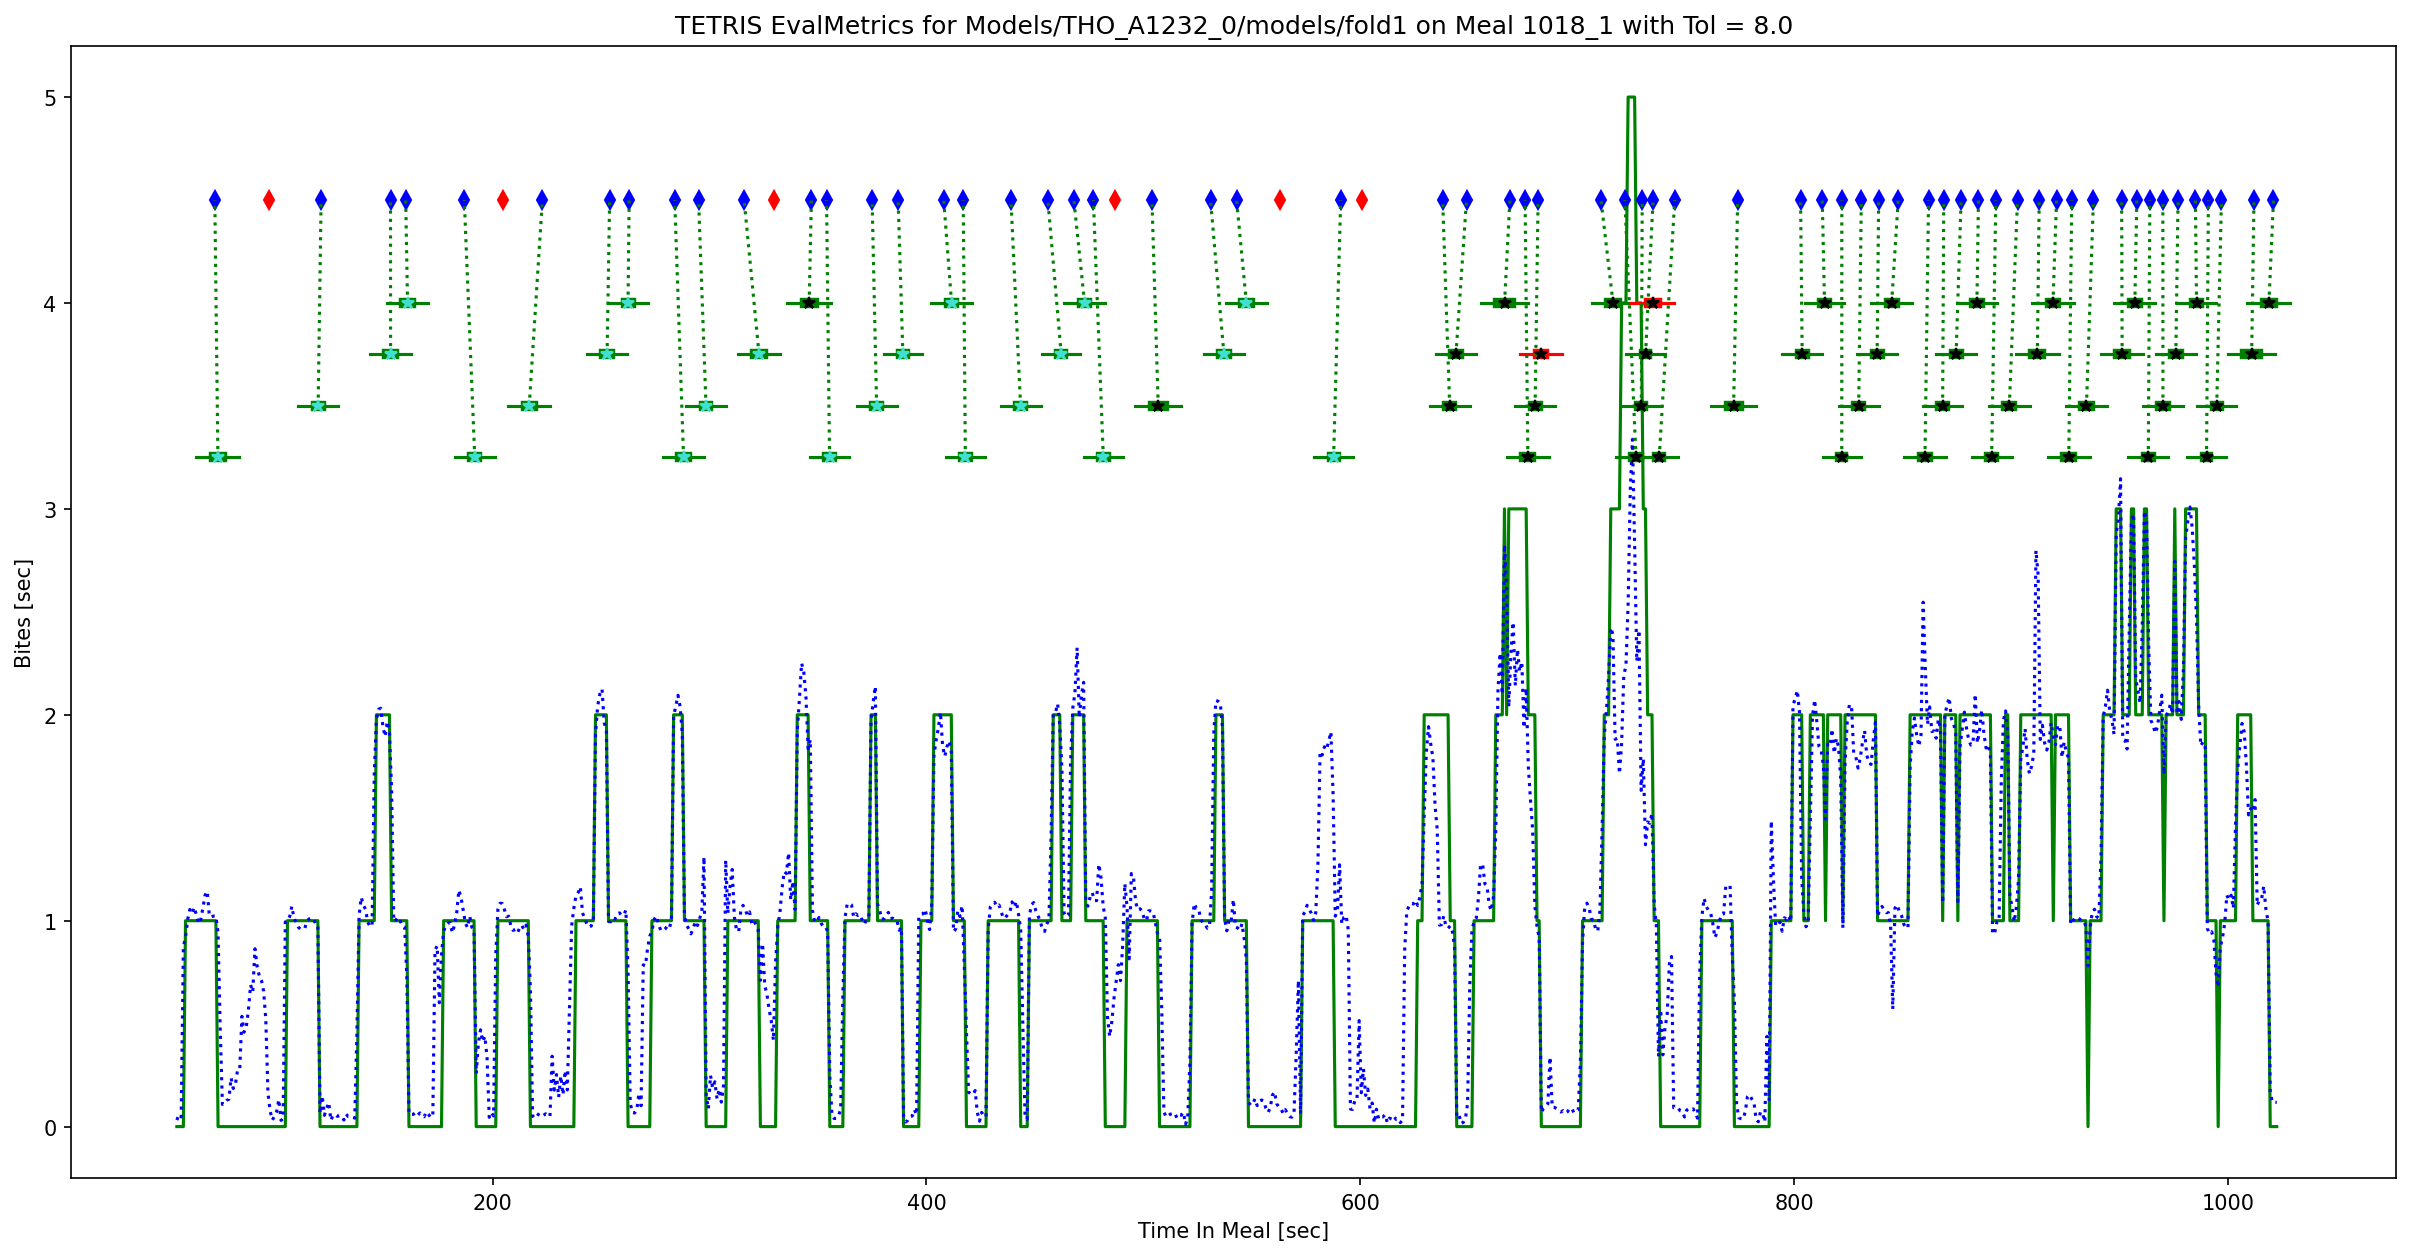

In [14]:
if DATABASE_FLAG == 1 or DATABASE_FLAG == 2:
	GT_Targets = GenerateTallyCounts(Window2TimePoint(gt_bite_times), timestep_ref, 15.0)
else:
	GT_Targets = GenerateTallyCounts(Window2TimePoint(gt_bite_times), timestep_ref, 15.0)
# end if

myFig = plt.figure('w',dpi=150)

myFig.set_figwidth(20)
myFig.set_figheight(10)

plt.plot(timestep_ref, GT_Targets, 'g-')
plt.plot(timestep_ref, predictions, ':b')

DETECT_AND_GT_OFFSET = 3
if True: # ADD GT WINDOWS
	cntr = 1
	numWindowLevels = 4
	for i in range(len(gt_bite_times)):
		x_data_tol = [gt_bite_times[i,0]-BEFORE_TOL, gt_bite_times[i,1]+AFTER_TOL]
		x_data = [gt_bite_times[i,0], gt_bite_times[i,1]]
		y_data = [DETECT_AND_GT_OFFSET+cntr/4, DETECT_AND_GT_OFFSET+cntr/4]
		
		if GT_MatchFlag[i] != -1:
			# plt.plot(x_data, y_data, 'g-')
			plt.plot(x_data_tol, y_data, 'g-')
			plt.plot(x_data, y_data, 'g-', linewidth = 5)
		else: # if GT MatchFlag[i] == -1 and is a FN
			# plt.plot(x_data, y_data, 'r-')
			plt.plot(x_data_tol, y_data, 'r-')
			plt.plot(x_data, y_data, 'r-', linewidth = 5)
		# end of if GT_MatchFlag
			
		cntr = (cntr%numWindowLevels)+1
	# end of for i in gt matches
# end of ADD GT WINDOWS

if True: # ADD DETECTIONS
	DetectionHeight = DETECT_AND_GT_OFFSET + 1.5
	# DetectionHeight = numWindowLevels
	
	# Add True Detections
	x_data = Detections[npDetectionOutcomes==0]
	y_data = np.ones(len(x_data)) * DetectionHeight
	plt.plot(x_data, y_data, 'bd')

	# Add FP Detections
	x_data = Detections[npDetectionOutcomes!=0]
	y_data = np.ones(len(x_data)) * DetectionHeight
	plt.plot(x_data, y_data, 'rd')
# end of ADD DETECTIONS

if True: # ADD CONNECTIONS BETWEEN PREDS AND DETECTIONS
	cntr = 1
	numWindowLevels = 4
	for i in range(len(gt_bite_times)):
		if GT_MatchFlag[i] != -1:
			x_data = [(gt_bite_times[i,0]+gt_bite_times[i,1])/2, Detections[GT_MatchFlag[i]]]
			y_data = [DETECT_AND_GT_OFFSET + cntr/4, DetectionHeight]
			plt.plot(x_data, y_data, 'g:')
		# end of if GT_MatchFlag
		
		cntr = (cntr%numWindowLevels)+1
	# end of for i in gt matches
# End of ADD CONNECTIONS


if True: # ADD Handedness Dot to GT WINDOWS
	cntr = 1
	numWindowLevels = 4
	for i in range(len(gt_bite_times)):
		x_data_tol = [gt_bite_times[i,0]-BEFORE_TOL, gt_bite_times[i,1]+AFTER_TOL]
		x_data = [(gt_bite_times[i,0]+gt_bite_times[i,1])/2]
		y_data = [DETECT_AND_GT_OFFSET+cntr/4]
		
		if currBiteHand[i] == currNonDomHand:
			# plt.plot(x_data, y_data, 'g-')
			plt.plot(x_data, y_data, color='turquoise', marker='*')
		else: # if Dominant Hand or Both Hands
			# plt.plot(x_data, y_data, 'r-')
			plt.plot(x_data, y_data, 'k*')
		# end of if GT_MatchFlag
			
		cntr = (cntr%numWindowLevels)+1
	# end of for i in gt matches
# end of ADD GT WINDOWS



plt.title("TETRIS EvalMetrics for {} on Meal {} with Tol = {}".format(MODEL_NAME, uniqueIDs[meal_num], WIN_TOLERANCE))
plt.xlabel("Time In Meal [sec]")
plt.ylabel("Bites [sec]")

# plt.xlim([130, 250])

if False:
	DatabaseNames = ["Names", "OHO", "THO", "Clem"]
	plt.savefig("Figures/TetrisV2_{}_{}_Tol{:02.0f}.pdf".format(DatabaseNames[DATABASE_FLAG], uniqueIDs[meal_num], WIN_TOLERANCE))
	# plt.savefig("Figures/TetrisV2_CumulativeError_{}_{}_Tol{:02.0f}.pdf".format(DatabaseNames[DATABASE_FLAG], uniqueIDs[meal_num], WIN_TOLERANCE))
	print("Finished Saving Figure")
# end of if Saving Figure

In [ ]:
# Generate Graph of detections and windows

myFig = plt.figure('w',dpi=150)

myFig.set_figwidth(20)
myFig.set_figheight(5)
plt.title("EvalMetrics for {} on Meal {} with Tol = {}".format(MODEL_NAME, meal_num, WIN_TOLERANCE))

if True: # ADD GT WINDOWS
	cntr = 1
	numWindowLevels = 4
	for i in range(len(gt_bite_times)):
		x_data_tol = [gt_bite_times[i,0]-BEFORE_TOL, gt_bite_times[i,1]+AFTER_TOL]
		x_data = [gt_bite_times[i,0], gt_bite_times[i,1]]
		y_data = [cntr/4, cntr/4]
		
		if GT_MatchFlag[i] != -1:
			# plt.plot(x_data, y_data, 'g-')
			plt.plot(x_data_tol, y_data, 'g-')
			plt.plot(x_data, y_data, 'g-', linewidth = 5)
		else: # if GT MatchFlag[i] == -1 and is a FN
			# plt.plot(x_data, y_data, 'r-')
			plt.plot(x_data_tol, y_data, 'r-')
			plt.plot(x_data, y_data, 'r-', linewidth = 5)
		# end of if GT_MatchFlag
			
		cntr = (cntr%numWindowLevels)+1
	# end of for i in gt matches

# end of ADD GT WINDOWS

if True: # ADD DETECTIONS
	DetectionHeight = 1.5
	# DetectionHeight = numWindowLevels
	
	# Add True Detections
	x_data = Detections[npDetectionOutcomes==0]
	y_data = np.ones(len(x_data)) * DetectionHeight
	plt.plot(x_data, y_data, 'bd')

	# Add FP Detections
	x_data = Detections[npDetectionOutcomes!=0]
	y_data = np.ones(len(x_data)) * DetectionHeight
	plt.plot(x_data, y_data, 'rd')
# end of ADD DETECTIONS

if True: # ADD CONNECTIONS BETWEEN PREDS AND DETECTIONS
	cntr = 1
	numWindowLevels = 4
	for i in range(len(gt_bite_times)):
		if GT_MatchFlag[i] != -1:
			x_data = [(gt_bite_times[i,0]+gt_bite_times[i,1])/2, Detections[GT_MatchFlag[i]]]
			y_data = [cntr/4, DetectionHeight]
			plt.plot(x_data, y_data, 'g:')
		# end of if GT_MatchFlag
		
		cntr = (cntr%numWindowLevels)+1
	# end of for i in gt matches
# End of ADD CONNECTIONS


plt.ylim([0,2])




print("Finished Generating Figure")

if False:
	plt.savefig("Figures/OHO_Meal96_Tol{:02.0f}.pdf".format(WIN_TOLERANCE))
	print("Finished Saving Figure")
# end of if Saving Figure


In [ ]:
Detections

In [ ]:
Detections